In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
import time as time
import pandas as pd
import math
import copy
import os

# Nice colours
colorsBlue = ['#b3e5fc', '#0091ea']
colorsRed = ['#f18e86', '#e83b47']
colorsYellow = ['#fb9d32', '#fec787']
colorsPurple = ['#d69bc5' ,'#a8509f']
colorsGreyOrange = ['#c3c3c3', '#f8a834']
colors = [colorsBlue, colorsRed, colorsYellow, colorsPurple, colorsGreyOrange]

# Nice cmap
import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', [colors[0][1], 'white', colors[1][1]])

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from utils.dataset import GeneralDataset
from utils.network import MODEL
from utils.graphs import analyse_connectivity
from utils.plots import *

In [3]:
# basic settings
encode_num = 4
decode_num = 4
k = encode_num
hidden_num = 32
LAYER_NUM = 3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

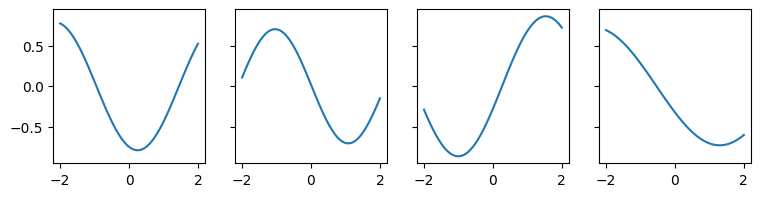

In [ ]:
seed = 145
np.random.seed(seed)

RUN_TYPE = 'nonlinear' # 'linear' for f(x) = x, or 'nonlinear' for randomly generated f(x)
folder = f'results_{RUN_TYPE}'
os.makedirs(folder, exist_ok = True)

amps = 0.7 + 0.3 * np.random.rand(encode_num) # * ((np.random.rand(encode_num) > 0) - 0.5)
fres = 0.4 + 1.4 * np.random.rand(encode_num) # 0.4, 0.4 for N8 and N16
phis = 2 * np.pi * np.random.rand(encode_num)
def morph(x):
	return amps * np.sin(fres * x + phis)
common_settings = {'L2' : 1e-4, 'bias' : True, 'nonlinear' : True, 'hidden_layer' : LAYER_NUM}

# plot to-be-learned functions
fig, axes = plt.subplots(1, encode_num, figsize = (9, 2), sharex = True, sharey = True)
xx = np.linspace(-2, 2, 100)
yy = np.array([morph([x] * encode_num) for x in xx])
for i in range(encode_num):
	axes[i].plot(xx, yy[:, i])

In [ ]:
baseline_losses = []
for i in range(encode_num):
    model = MODEL(encode_num = 1,
              decode_num = 1,
              hidden_num = round(hidden_num / encode_num),
              **(common_settings))
    model.to(device)

    train_dataset = GeneralDataset(encode_num = 1,mapfun = lambda x: amps[i] * np.sin(fres[i] * x + phis[i]), num_samples = 1000)
    test_dataset = GeneralDataset(encode_num = 1, mapfun = lambda x: amps[i] * np.sin(fres[i] * x + phis[i]), num_samples = 1000)
    train_dataloader = DataLoader(train_dataset, batch_size = 200)

    lr = 1e-3
    wd = 0 # using explicit L2 regularisation
    num_epochs = 10000
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr = lr, weight_decay = wd)

    # Training loop
    losses = []
    model.train()
    for epoch in range(num_epochs):
        losses.append(model.fit(train_dataloader, train_dataset, test_dataset, optimizer, criterion, device))
        print(f'epoch {epoch:07d}, test loss {losses[-1][0]:.5f}, valid vloss {losses[-1][1]:.5f}, L2 norm {losses[-1][3]:.5f}', end = '\r')
    losses = np.array(losses)
    print()
    baseline_losses.append(losses[-1][1])

epoch 0009999, test loss 0.00001, valid vloss 0.00001, L2 norm 5.959569
epoch 0009999, test loss 0.00006, valid vloss 0.00007, L2 norm 8.571534


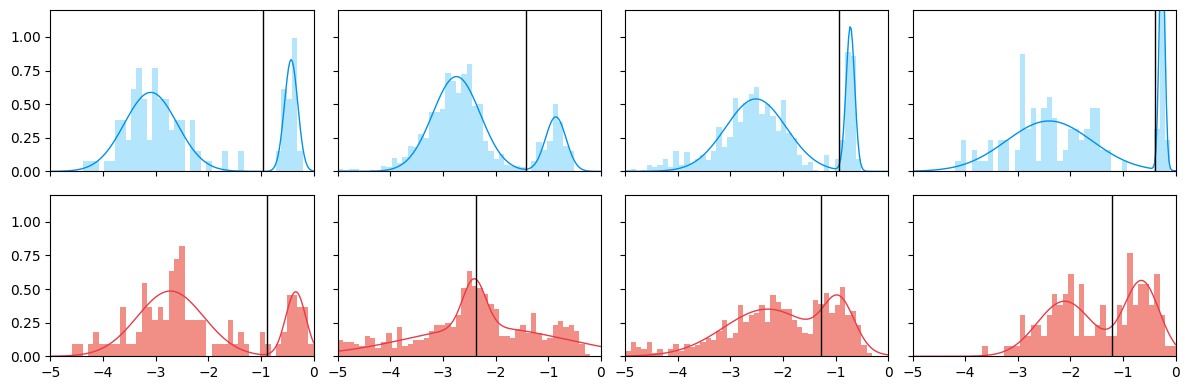

In [ ]:
def double_normal(x, mu1, sigma1, mu2, sigma2, alpha):
    return alpha * sp.stats.norm.pdf(x, mu1, sigma1) + (1 - alpha) * sp.stats.norm.pdf(x, mu2, sigma2)

models = ['WeightedAct', 'L2']
fig, axes = plt.subplots(len(models), 4, figsize = (12, 4), sharex = True, sharey = True)
pruned_models = []
for j in range(len(models)):
    
    model = torch.load(f'results_nonlinear/{models[j]}/model.pth', weights_only = False)
    pruned_model = copy.deepcopy(model)
    idxes = []
    for idx, layer in enumerate(pruned_model.layer):
        if isinstance(layer, nn.Linear):
            idxes.append(idx)
    for i in range(4):
        weights = model.layer[idxes[i]].weight.detach().numpy()
        weights = np.log10(np.abs(weights.flatten()))
        hist, bin_edges = np.histogram(weights, bins = np.linspace(-5, 0, 50), density = True)
        _xx = (bin_edges[:-1] + bin_edges[1:]) / 2
        _yy = hist
        # fit a double normal distribution to the histogram of weights
        popt, _ = sp.optimize.curve_fit(double_normal, _xx, _yy, p0 = [-2.5, 1.5, -0.5, 1.5, 0.5])
        
        axes[j, i].hist(weights, bins = np.linspace(-5, 0, 50), color = colors[j][0], density = True)
        x = np.linspace(-5, 0, 200)
        axes[j, i].plot(x, double_normal(x, *popt), color = colors[j][1], lw = 1)
        mu1, sigma1, mu2, sigma2, alpha = popt
        separator = (1/sigma1 * mu1 + 1/sigma2 * mu2) / (1/sigma1 + 1/sigma2)
        axes[j, i].axvline(separator, color = 'black', lw = 1)
        pruned_model.layer[idxes[i]].weight.data[torch.abs(model.layer[idxes[i]].weight) < 10 ** separator] = 0
        axes[j, i].set_xlim(-5, 0)
        axes[j, i].set_ylim(0, 1.2)
    pruned_models.append(pruned_model)
plt.tight_layout()
# plt.savefig('temp.pdf')

In [120]:
# training and test datasets
change_factors = np.logspace(-1, 3, 51)
ERRS = np.zeros((len(change_factors), encode_num, len(pruned_models)))
OUTS = np.zeros((len(change_factors), 1000, encode_num, len(pruned_models)))
TGTS = np.zeros((len(change_factors), 1000, encode_num))
INPS = np.zeros((len(change_factors), 1000, encode_num, len(pruned_models)))
for i in range(len(pruned_models)):
    model = pruned_models[i]
    
    for j, change_factor in enumerate(change_factors):
        test_dataset = GeneralDataset(encode_num = encode_num, mapfun = morph, num_samples = 1000)
        test_dataset.data[:, 0] += change_factor
        test_dataset.__generate__()
        
        outputs, _ = model(torch.tensor(test_dataset.data, dtype = torch.float))
        outputs = outputs.detach().numpy()
        errors = np.mean((outputs - test_dataset.targets) ** 2, axis = 0)
        ERRS[j, :, i] = errors
        OUTS[j, :, :, i] = outputs
        TGTS[j, :, :] = test_dataset.targets
        INPS[j, :, :, i] = test_dataset.data

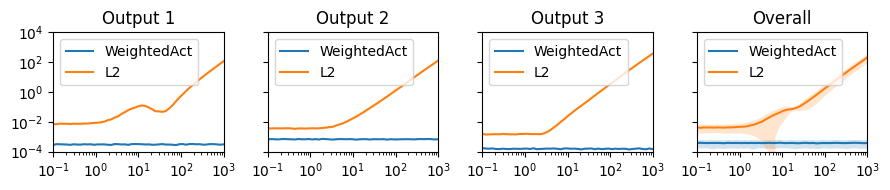

In [ ]:
fig, axes = plt.subplots(1, encode_num, figsize = (9, 2), sharex = True, sharey = True)
for i in range(encode_num - 1):
    for j in range(len(pruned_models)):
        axes[i].plot(change_factors, ERRS[:, i + 1, j], label = models[j])
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')
    axes[i].set_title(f'Output {i + 1}')
    axes[i].legend()
for j in range(len(pruned_models)):
    axes[-1].plot(change_factors, np.mean(ERRS[:, 1:, j], axis = 1), label = models[j])
    axes[-1].fill_between(change_factors, np.mean(ERRS[:, 1:, j], axis = 1) - np.std(ERRS[:, 1:, j], axis = 1), np.mean(ERRS[:, 1:, j], axis = 1) + np.std(ERRS[:, 1:, j], axis = 1), alpha = 0.2)
axes[-1].set_xscale('log')
axes[-1].set_yscale('log')
axes[-1].set_title(f'Overall')
axes[-1].set_xlim(1e-1, 1e3)
axes[-1].set_ylim(1e-4, 1e4)
axes[-1].legend()
plt.tight_layout()
# plt.savefig('temp2.pdf')

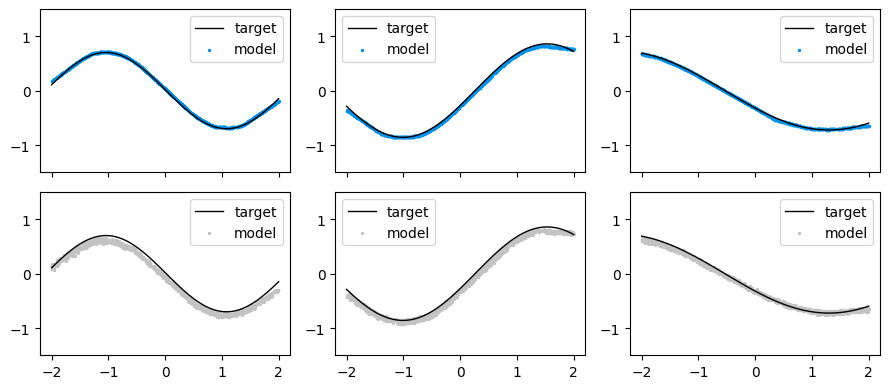

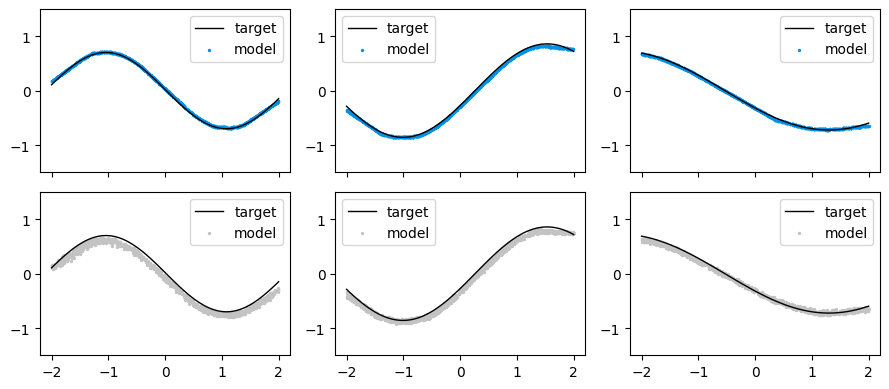

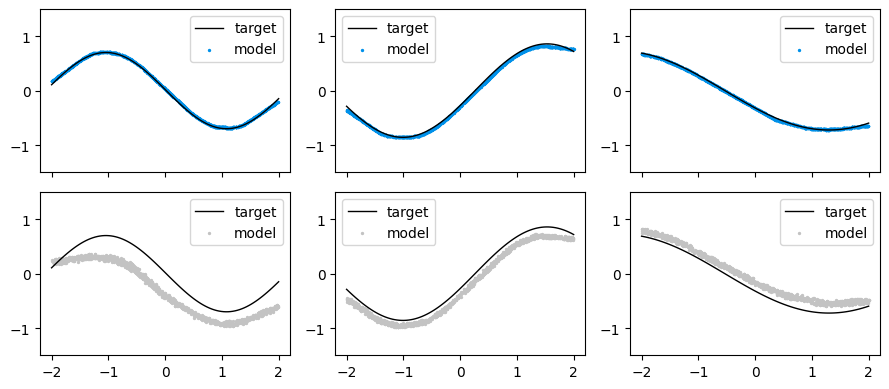

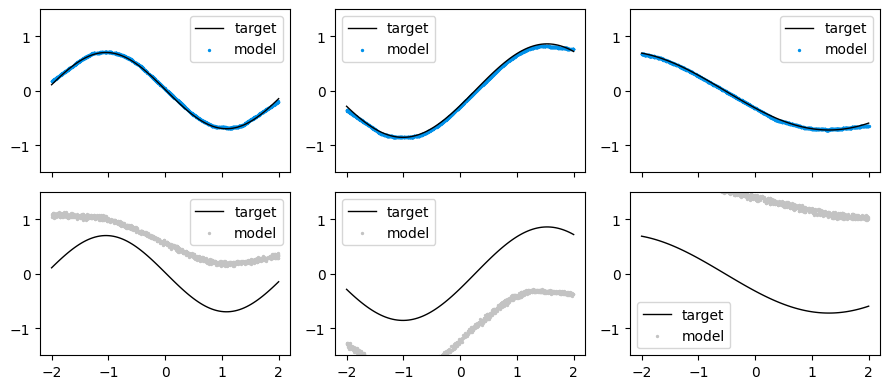

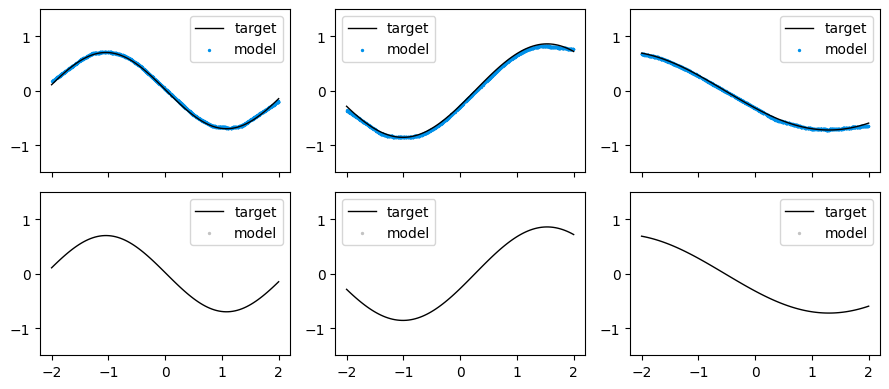

In [8]:
scaleidxs = [0, 12, 25,37,50]
for scaleidx in scaleidxs:
    fig, axes = plt.subplots(len(pruned_models), encode_num - 1, figsize = (9, 4), sharex = True)#, sharey = True)
    for i in range(encode_num - 1):
        for j in range(len(pruned_models)): # results for different models
            axes[j, i].plot(xx, yy[:, i + 1], label = 'target', color = 'black', lw = 1)
            axes[j, i].scatter(INPS[scaleidx, :, i + 1, j], OUTS[scaleidx, :, i + 1, j], label = 'model', color = colors[j * 4][1 - j], s = 2)
            axes[j, i].legend()
            axes[j, i].set_xlim(-2.2, 2.2)
            axes[j, i].set_ylim(-1.5, 1.5)
    plt.tight_layout()
    # plt.savefig(f'temp3_{scaleidx}.pdf')